# Pre-Processing


1) cut out the first and last 1.5s from the recordings (they’re influenced by the touching of the screen to hit the record/end recording button);

2) Pass band filter to keep only the interesting frequencies;

3) Division of the recording into set windows;

4) Delete not significative windows (check delta between all consecutive measurements + deceleration in past windows) (create one dataset keeping not significative windows and one Fourier transform;

5) Calcolare mean, variance, standard deviation, min, max, difference between min and max, …


In [2]:
# Cut-Out script

import os
import pandas as pd

RAW_REC_DIR = "../raw_data"
PRE_PROCESSING_DIR = "../preprocessing"
CUT_OUT_DIR = PRE_PROCESSING_DIR + "/cut_out_start_end"
SENSOR_FILES = ["Accelerometer.csv", "Gyroscope.csv", "Gravity.csv"]

# Read recordings in each folder and cut the first and last 1.5 seconds meausurements

for recording in os.listdir(RAW_REC_DIR):

    #print(f"Processing {recording}...")
    recording_path = os.path.join(RAW_REC_DIR, recording)
    cutout_recording_path = os.path.join(CUT_OUT_DIR, recording)

    if not os.path.exists(cutout_recording_path):
        os.makedirs(cutout_recording_path)

    for measurement_type in os.listdir(recording_path):

        if measurement_type in SENSOR_FILES:

            raw_file_path = os.path.join(recording_path, measurement_type)
            cutout_file_path = os.path.join(cutout_recording_path, measurement_type)

            # Read the CSV file with pandas

            # pd.read_csv() loads the CSV into a Pandas DataFrame:
            # a tabular structure (map or dictionary) where each column contains an array of values
            # associated with a common row index.
            data = pd.read_csv(raw_file_path)

            # Cut the first and last 1.5 seconds of measurements
            sampling_rate = 100  # Assuming a sampling rate of 100 Hz
            cut_samples = int(1.5 * sampling_rate)

            # Ensure we have enough data to cut
            if len(data) > 2 * cut_samples:
                # iloc selects rows by integer position, excluding the first and last cut_samples rows.
                cut_data = data.iloc[cut_samples:-cut_samples]
                #index=False tells pandas not to save the DataFrame’s row index as an extra column in the CSV file.
                cut_data.to_csv(cutout_file_path, index=False)
                print(f"Processed {recording}: Cut first and last 1.5 seconds.")
            else:
                print(f"Skipping {recording}: Not enough data to cut.")



Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seconds.
Processed bumpy_stadio: Cut first and last 1.5 seconds.
Processed bumpy_stadio: Cut first and last 1.5 seconds.
Processed bumpy_stadio: Cut first and last 1.5 seconds.
Processed bumpy_stazione: Cut first and last 1.5 seconds.
Processed bumpy_stazione: Cut first and last 1.5 seconds.
Processed bumpy_stazione: Cut first and last 1.5 seconds.
Processed bumpy_stradabumpy_con_rialzi_e_buche-2026-09-21_13-44-51: Cut first and last 1.5 seconds.
Pro

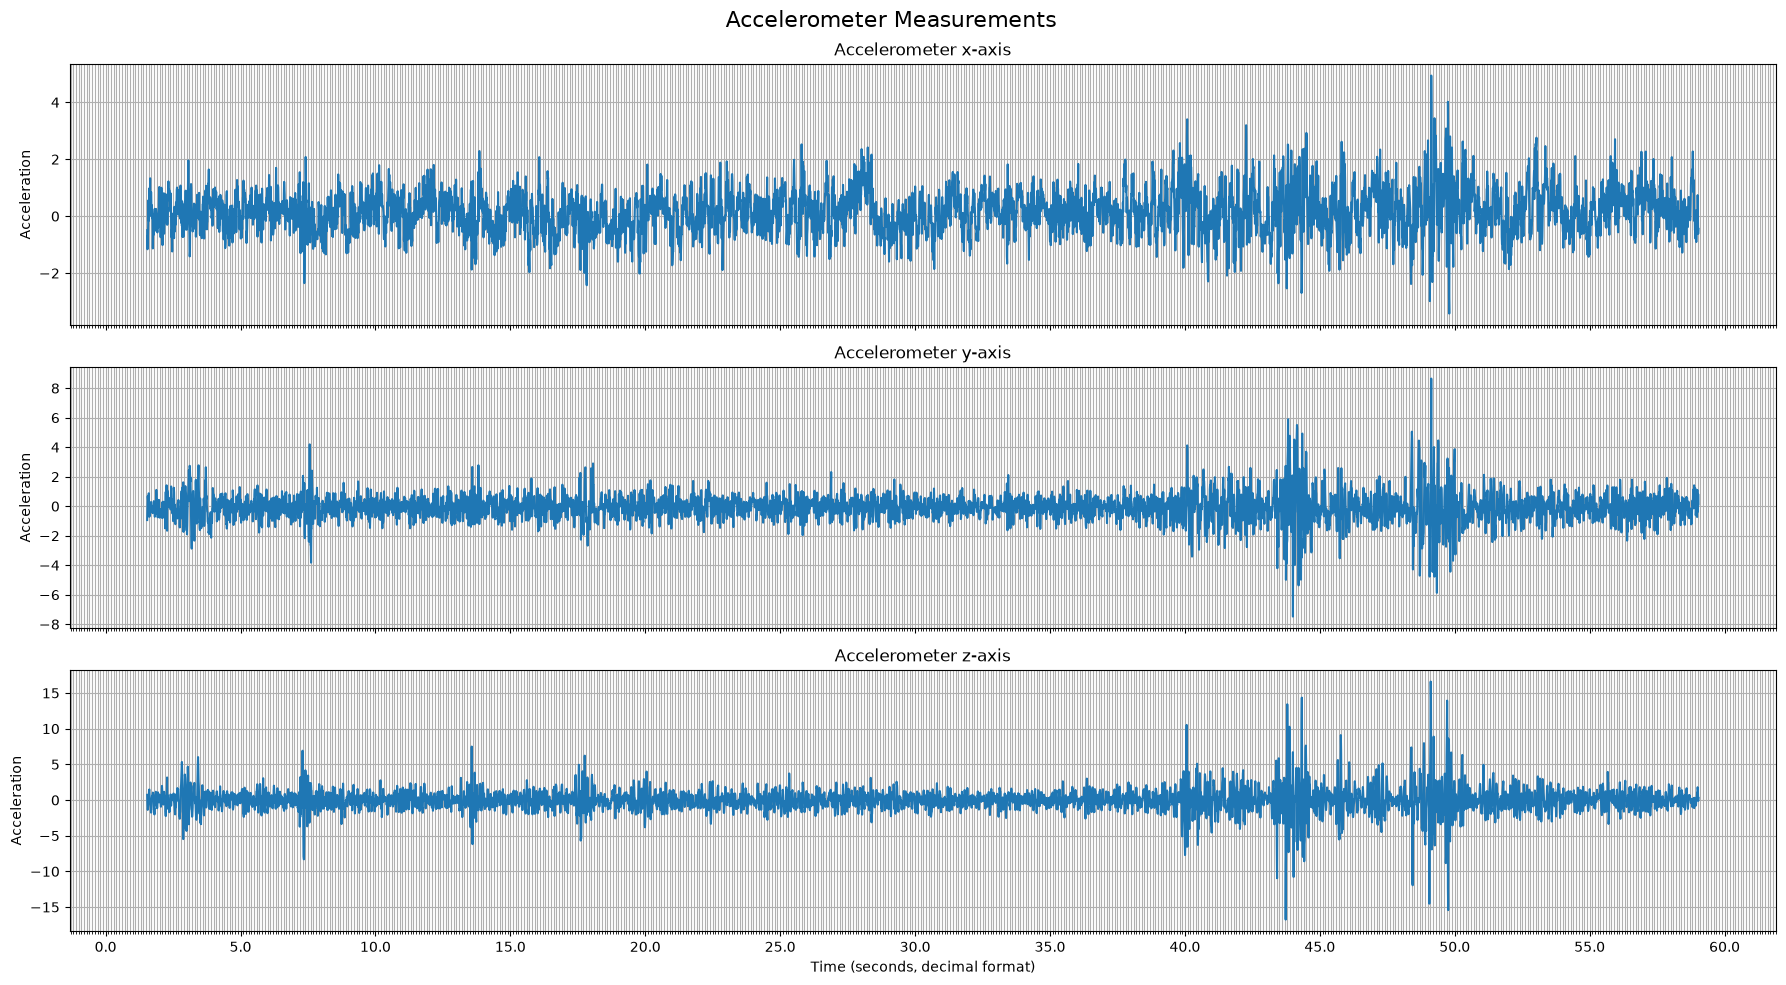

In [3]:
# Plotting script for visualizing the effect of preprocessing steps

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter



# Load one accelerometer recording into a DataFrame
data = pd.read_csv(CUT_OUT_DIR + "/bumpy_stadio/Accelerometer.csv")

# Create one plot for each accelerometer axis
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

for axis, axis_name in zip(axes, ["x", "y", "z"]):
    axis.plot(data["seconds_elapsed"], data[axis_name])
    axis.set_title(f"Accelerometer {axis_name}-axis")
    axis.set_ylabel("Acceleration")
    axis.grid(True, which="both")
    axis.xaxis.set_major_locator(MultipleLocator(5.0))
    axis.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axis.xaxis.set_minor_locator(MultipleLocator(0.1))

axes[-1].set_xlabel("Time (seconds, decimal format)")
fig.suptitle("Accelerometer Measurements", fontsize=16)
fig.tight_layout()
plt.show()


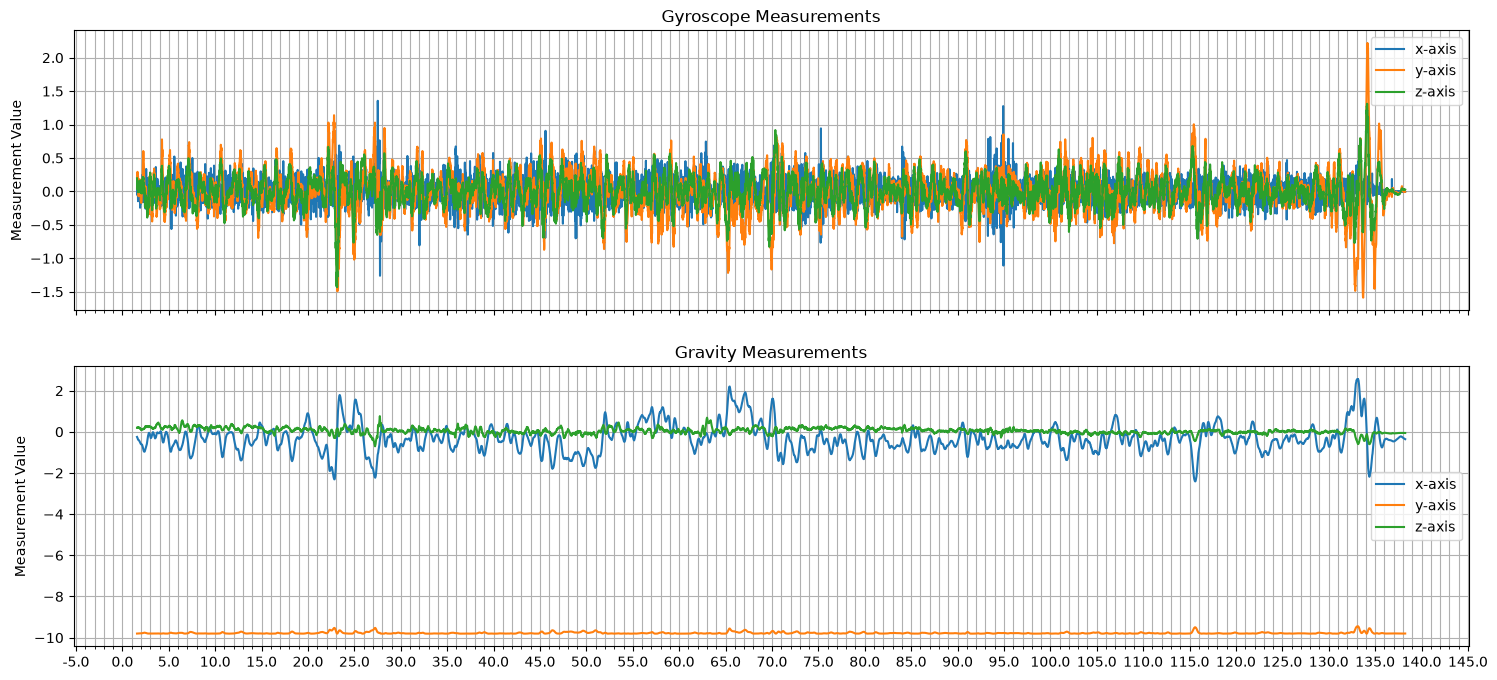

In [14]:
# plot the giroscope and gravity measurements

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
for i, measurement_type in enumerate(["Gyroscope", "Gravity"]):
    data = pd.read_csv(CUT_OUT_DIR + f"/bumpy_con_tante_buche-2026-09-21_13-24-26/{measurement_type}.csv")
    for axis_name in ["x", "y", "z"]:
        axes[i].plot(data["seconds_elapsed"], data[axis_name], label=f"{axis_name}-axis")
    axes[i].set_title(f"{measurement_type} Measurements")
    axes[i].set_ylabel("Measurement Value")
    axes[i].grid(True, which="both")
    axes[i].xaxis.set_major_locator(MultipleLocator(5.0))
    axes[i].xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[i].xaxis.set_minor_locator(MultipleLocator(1.0))
    axes[i].legend()



# Stationary segment removal

We want to remove the stationary segment because they do not influence the final decision of the class of the road

**PSEUDOCODE**

FOR each recording:

    magnitude = sqrt(ax^2 + ay^2 + az^2)   # ax,ay,az from Accelerometer.csv (already gravity-free)

    energy = rolling_window(magnitude^2, window=short_window_size).mean()

    is_stationary = energy < threshold

    # require minimum consecutive duration before accepting as "stationary"

    is_stationary = enforce_min_duration(is_stationary, min_seconds=1.0)
    
    recording = recording[NOT is_stationary]   # or mark/exclude at windowing stage, preserving timestamps

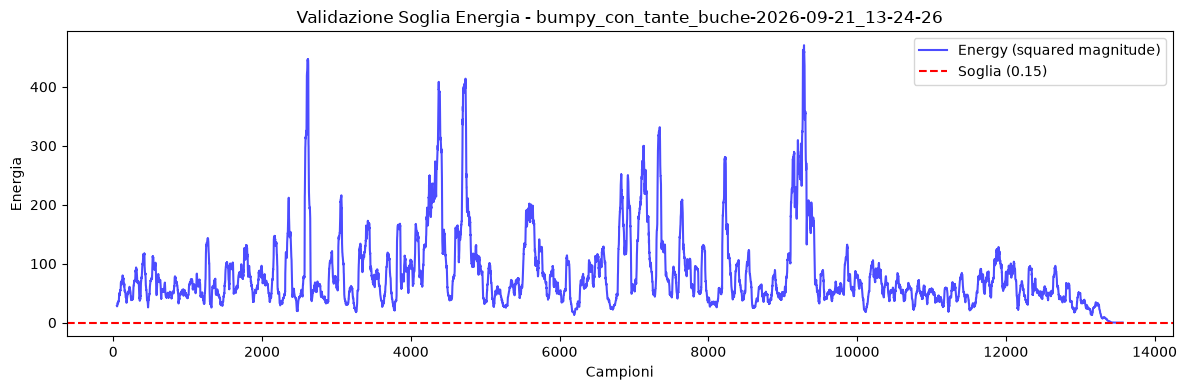

In [5]:
# stationary segment removal script
import pandas as pd
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "../preprocessing/cut_out_remove_stationary" # Dove vuoi salvare i nuovi dati

VALIDATE_PLOT = True  # Set to True to visualize the energy and threshold for validation

#for each recording, remove the stationary segments based on the accelerometer data
for recording in os.listdir(CUT_OUT_DIR):
    accelerometer_file_path = os.path.join(CUT_OUT_DIR, recording, "Accelerometer.csv")
    accelerometer_data = pd.read_csv(accelerometer_file_path)
    gyroscope_file_path = os.path.join(CUT_OUT_DIR, recording, "Gyroscope.csv")
    gyroscope_data = pd.read_csv(gyroscope_file_path)
    gravity_file_path = os.path.join(CUT_OUT_DIR, recording, "Gravity.csv")
    gravity_data = pd.read_csv(gravity_file_path)

    MAX_ALLOWED_DIFF = 5  # Allow up to 5 samples of difference
    
    lengths = {
        'Acc': len(accelerometer_data),
        'Gyro': len(gyroscope_data),
        'Grav': len(gravity_data)
    }
    
    max_len = max(lengths.values())
    min_len = min(lengths.values())
    
    # Raise error only if the difference is actually problematic
    if (max_len - min_len) > MAX_ALLOWED_DIFF:
        raise ValueError(f"CRITICAL ERROR in {recording}: Sensors are out of sync! "
                         f"Difference is {max_len - min_len} (max allowed: {MAX_ALLOWED_DIFF}). "
                         f"Lengths: {lengths}")
    
    # Truncate all DataFrames to the shortest length to ensure perfect alignment (by creating copies of the DataFrames)
    # This prevents Pandas boolean indexing crashes if one sensor has 1-2 extra rows.
    acc_work= accelerometer_data.iloc[:min_len]
    gyr_work = gyroscope_data.iloc[:min_len]
    grav_work = gravity_data.iloc[:min_len]

    # Calculate the magnitude of the accelerometer data
    magnitude = (acc_work["x"]**2 + acc_work["y"]**2 + acc_work["z"]**2)**0.5
    energy_threshold = 0.15  # Define a threshold for stationary segments

    # Calculate the energy of the accelerometer data using rolling window mean of the squared magnitude
    energy = (magnitude**2).rolling(window=50).mean()  # Adjust window size as needed

    # Plot the energy and threshold for validation
    if VALIDATE_PLOT:
        plt.figure(figsize=(12, 4))
        plt.plot(energy, label='Energy (squared magnitude)', color='blue', alpha=0.7)
        plt.axhline(y=energy_threshold, color='red', linestyle='--', label=f'Soglia ({energy_threshold})')
        plt.title(f"Validazione Soglia Energia - {recording}")
        plt.xlabel("Campioni")
        plt.ylabel("Energia")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        # IMPORTANTE: Dopo aver visto il primo grafico e confermato la soglia, 
        # cambia VALIDATE_PLOT = False qui sopra per non bloccare il loop sui file successivi.
        input("Premi Invio per continuare con gli altri file...")
        VALIDATE_PLOT = False

    # Identify stationary segments where energy is below the threshold
    stationary_segments = energy < energy_threshold

    # require that stationary segments are at least 2 seconds long (200 samples at 100 Hz)
    min_stationary_length = 200

    # 1. assign a unique ID to each run of consecutive True values in stationary_segments
    run_ids = (stationary_segments != stationary_segments.shift()).cumsum()
    
    # 2. compute the length of each run of consecutive True values
    run_lengths = stationary_segments.groupby(run_ids).transform('size')
    
    # 3. keep only the runs of consecutive True values that are at least min_stationary_length long
    stationary_segments = stationary_segments & (run_lengths >= min_stationary_length)

    # Remove stationary segments from the all data
    filtered_accelerometer_data = acc_work[~stationary_segments]
    filtered_gyroscope_data = gyr_work[~stationary_segments]
    filtered_gravity_data = grav_work[~stationary_segments]
    
    # create a new folder in preprocessing called cut_out_remove_stationary to store the filtered accelerometer data
    new_folder_path = os.path.join(OUTPUT_DIR, recording)
    os.makedirs(new_folder_path, exist_ok=True)

    # Save the filtered data
    filtered_accelerometer_data.to_csv(os.path.join(new_folder_path, "Accelerometer.csv"), index=False)
    filtered_gyroscope_data.to_csv(os.path.join(new_folder_path, "Gyroscope.csv"), index=False)
    filtered_gravity_data.to_csv(os.path.join(new_folder_path, "Gravity.csv"), index=False)

# Check to see if any part was removed

By plotting the data before and after the stationary parts removal, we can see the differences

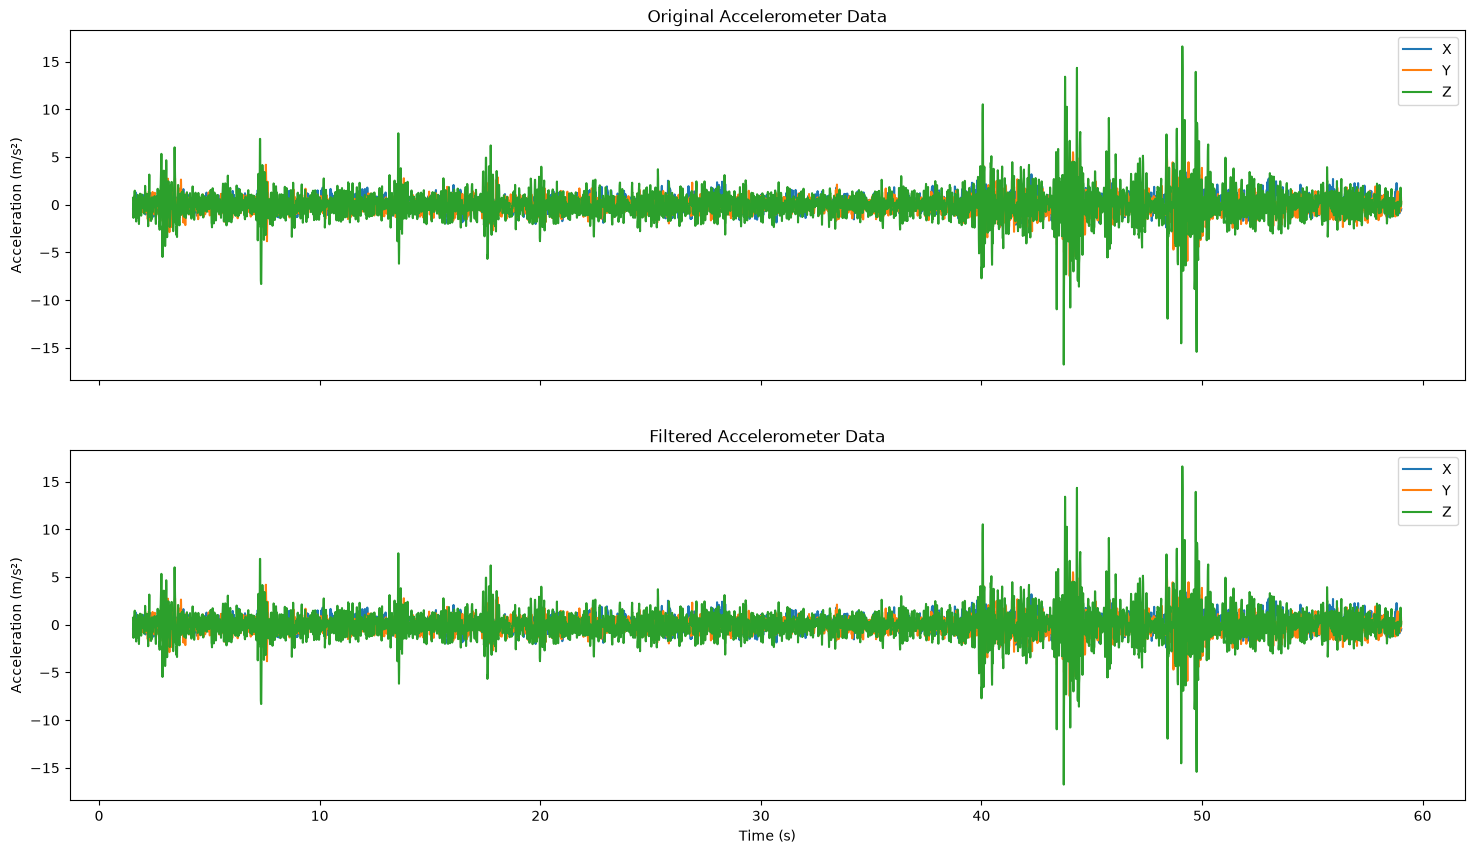

In [10]:
# plot the data pre and post stationary removal for validation
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the original and filtered accelerometer data for a specific recording
recording = "bumpy_stadio"  # Replace with the desired recording name
original_accelerometer_data = pd.read_csv(os.path.join(CUT_OUT_DIR, recording, "Accelerometer.csv"))
filtered_accelerometer_data = pd.read_csv(os.path.join(OUTPUT_DIR, recording, "Accelerometer.csv"))

# 2. Create a figure with two subplots: one for the original data and one for the filtered data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# 3. Plot the original accelerometer data
ax1.plot(original_accelerometer_data['seconds_elapsed'], original_accelerometer_data['x'], label='X')
ax1.plot(original_accelerometer_data['seconds_elapsed'], original_accelerometer_data['y'], label='Y')
ax1.plot(original_accelerometer_data['seconds_elapsed'], original_accelerometer_data['z'], label='Z')
ax1.set_title('Original Accelerometer Data')
ax1.set_ylabel('Acceleration (m/s²)')
ax1.legend()

# 4. Plot the filtered accelerometer data
ax2.plot(filtered_accelerometer_data['seconds_elapsed'], filtered_accelerometer_data['x'], label='X')
ax2.plot(filtered_accelerometer_data['seconds_elapsed'], filtered_accelerometer_data['y'], label='Y')
ax2.plot(filtered_accelerometer_data['seconds_elapsed'], filtered_accelerometer_data['z'], label='Z')
ax2.set_title('Filtered Accelerometer Data')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Acceleration (m/s²)')
ax2.legend()




As we can see the two plots are exactly the same, and it is what we were expecting since in this registration we always were in movement, but there can be some cases in the future where or from other registrations where we had to stop, due to circumstances, and this procedure cut out the parts where we stayed fixed

# Orientation alignment

The physical orientation (tilt) of the smartphone varies between different bike rides. Because of this, a vertical event like a pothole might be recorded primarily on the X-axis in one ride, and on the Z-axis in another. 

To solve this, we use the `Gravity` sensor to find the true "down" direction for each recording. By projecting the raw sensor data onto this gravity vector, we mathematically "level" the phone. This transforms the data into two universal, orientation-independent components:
* **Vertical (`vert`)**: Captures road irregularities (bumps, potholes).
* **Horizontal (`horiz`)**: Captures forward motion (pedaling, steering).

This ensures our model learns to recognize actual road conditions, regardless of how the phone was mounted.

In [15]:
# Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

def align_measurements_by_gravity(sensor_data, g_hat):
    """
    Aligns the sensor measurements based on the direction of gravity.

    Parameters:
    - sensor_data: DataFrame containing the sensor measurements (x, y, z).
    - g_hat: Normalized mean gravity vector.

    Returns:
    - aligned_data: DataFrame containing the aligned sensor measurements.
    """

    # Get all x,y,z values as a numpy array (shape: N_samples × 3)
    sensor_vectors = sensor_data[['x', 'y', 'z']].values

    # 1. Calculate the SCALAR projection (the actual vertical value)
    # Shape: (N,)
    vertical_scalar = np.dot(sensor_vectors, g_hat) 

    # 2. Calculate the 3D vertical vector (for subtracting later)
    # Shape: (N, 3)
    vertical_vector = vertical_scalar[:, np.newaxis] * g_hat

    # 3. Calculate the horizontal component vector
    horizontal_component = sensor_vectors - vertical_vector

    # 4. Calculate horizontal magnitudes (norm along axis 1)
    horizontal_magnitudes = np.linalg.norm(horizontal_component, axis=1)

    # Create a new DataFrame with the aligned sensor measurements
    aligned_data = sensor_data.copy()
    aligned_data['vertical'] = vertical_scalar
    aligned_data['horizontal'] = horizontal_magnitudes

    return aligned_data


# Perform the alignment of measurements from different registrations based on the direction of gravity.

# we must do this for each recording, and for each sensor (accelerometer, gyroscope, gravity), we must align the measurements based on the direction of gravity. 
# this is important because the direction of gravity can change depending on how the device is oriented during the recording.

INPUT_DIR_2 = "../preprocessing/cut_out_remove_stationary"
OUTPUT_DIR_2 = "../preprocessing/cut_out_remove_stationary_aligned"

# Create the output directory if it doesn't exist
os.makedirs(OUTPUT_DIR_2, exist_ok=True)

# Iterate through each recording in the input directory
for recording in os.listdir(INPUT_DIR_2):
    recording_path = os.path.join(INPUT_DIR_2, recording)
    output_recording_path = os.path.join(OUTPUT_DIR_2, recording)
    
    # Create the output directory for the current recording if it doesn't exist
    os.makedirs(output_recording_path, exist_ok=True)
    
    # Load the gravity data for the current recording
    gravity_data = pd.read_csv(os.path.join(recording_path, "Gravity.csv"))
    
    # Step 1: Calculate g_hat (mean gravity direction, normalized)
    g_mean = gravity_data[["x", "y", "z"]].mean().values
    g_hat = g_mean / np.linalg.norm(g_mean)  # Normalize the mean gravity vector

    # print the phone tilt in degrees from vertical based on the gravity vector
    print(f"Phone tilt: {np.degrees(np.arccos(np.abs(g_hat[2]))):.1f}° from vertical")
    

    # Step 2: Align the measurements for each sensor based on g_hat
    for sensor in ["Accelerometer", "Gyroscope", "Gravity"]:
        sensor_data = pd.read_csv(os.path.join(recording_path, f"{sensor}.csv"))
        aligned_data = align_measurements_by_gravity(sensor_data, g_hat)
        
        # Save the aligned data to the output directory
        aligned_data.to_csv(os.path.join(output_recording_path, f"{sensor}_aligned.csv"), index=False)

print("✅ Alignment complete!")

Phone tilt: 89.7° from vertical
Phone tilt: 76.1° from vertical
Phone tilt: 54.6° from vertical
Phone tilt: 55.0° from vertical
Phone tilt: 75.6° from vertical
Phone tilt: 55.7° from vertical
Phone tilt: 89.2° from vertical
Phone tilt: 89.8° from vertical
Phone tilt: 76.0° from vertical
Phone tilt: 54.7° from vertical
Phone tilt: 55.4° from vertical
Phone tilt: 89.5° from vertical
Phone tilt: 50.0° from vertical
✅ Alignment complete!


If we go into the new directory, we should see that the gravity's vertical and horizontal component that are identic in all the registrations (make sense since we aligned based on gravity)

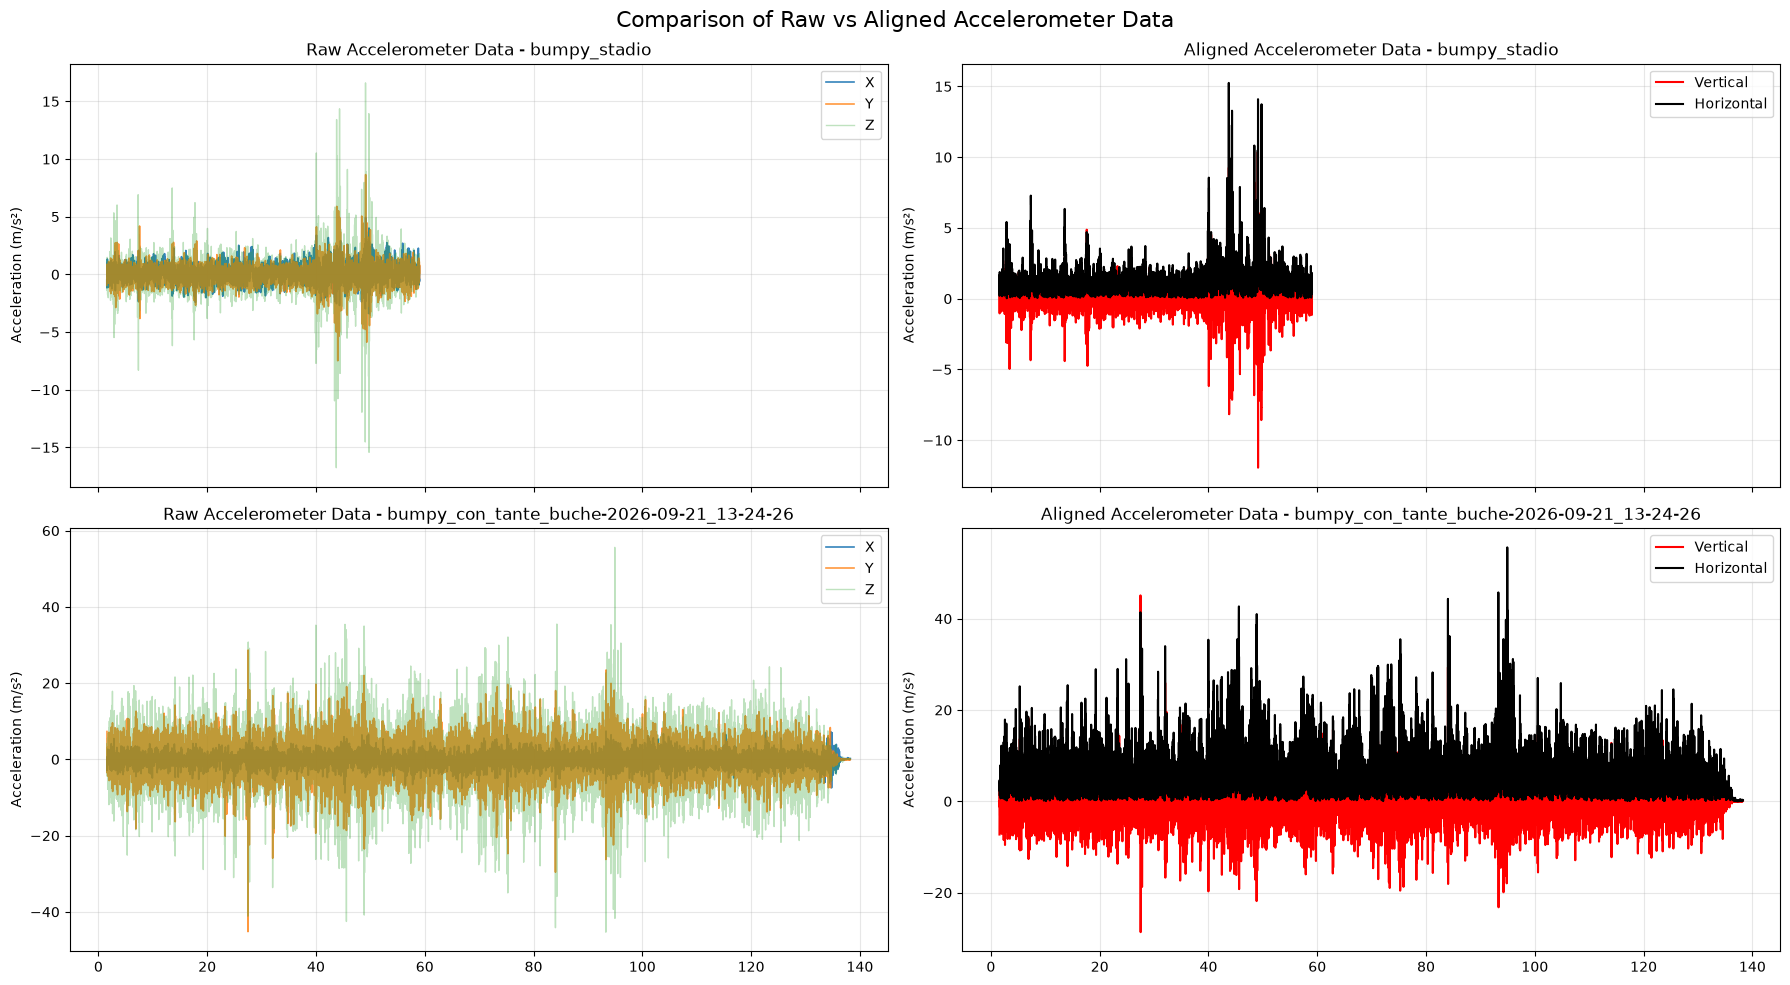

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Recording to compare
recording = ["bumpy_stadio", "bumpy_con_tante_buche-2026-09-21_13-24-26"]

# paths : INPUT_DIR_2 and OUTPUT_DIR_2

# create figure with 2 subplots: 2 recordings x 2 plots (raw vs aligned)
fig, axes = plt.subplots(len(recording), 2, figsize=(18, 10), sharex=True)

for idx, rec in enumerate(recording):
    # Load the raw and aligned accelerometer data
    raw_data = pd.read_csv(os.path.join(INPUT_DIR_2, rec, "Accelerometer.csv"))
    aligned_data = pd.read_csv(os.path.join(OUTPUT_DIR_2, rec, "Accelerometer_aligned.csv"))
    
    # Left column: Raw data
    ax_left = axes[idx, 0] if len(rec) > 1 else axes[0]
    ax_left.plot(raw_data['seconds_elapsed'], raw_data['x'], label='X', alpha=0.9, linewidth=1.2)
    ax_left.plot(raw_data['seconds_elapsed'], raw_data['y'], label='Y', alpha=0.8, linewidth=1.2)
    ax_left.plot(raw_data['seconds_elapsed'], raw_data['z'], label='Z', alpha=0.3, linewidth=1)
    ax_left.set_title(f'Raw Accelerometer Data - {rec}')
    ax_left.set_ylabel('Acceleration (m/s²)')
    ax_left.legend(loc='upper right')
    ax_left.grid(True, alpha=0.3)

    # Right column: Aligned data
    ax_right = axes[idx, 1] if len(rec) > 1 else axes[1]
    ax_right.plot(aligned_data['seconds_elapsed'], aligned_data['vertical'], label='Vertical', color='red')
    ax_right.plot(aligned_data['seconds_elapsed'], aligned_data['horizontal'], label='Horizontal', color='black')
    ax_right.set_title(f'Aligned Accelerometer Data - {rec}')
    ax_right.set_ylabel('Acceleration (m/s²)')
    ax_right.legend(loc='upper right')
    ax_right.grid(True, alpha=0.3)

plt.suptitle("Comparison of Raw vs Aligned Accelerometer Data", fontsize=16)
plt.tight_layout()
plt.show()

### Figure: Raw vs. Aligned Accelerometer Data

The plots above demonstrate the effectiveness of the gravity-based orientation alignment. 

*   **Left Column (Raw Data):** The raw X, Y, and Z axes are heavily dependent on the physical orientation of the smartphone during the recording. For instance, in the bottom recording (`bumpy_con_tante_buche`), the Z-axis dominates the scale (reaching ±60 m/s²), completely obscuring the X and Y components. Comparing the two raw signals directly is misleading because the phone was mounted differently.
*   **Right Column (Aligned Data):** By projecting the 3D sensor data onto the mean gravity vector ($g\_hat$), we transform the measurements into a universal, orientation-independent coordinate system. 
    *   The **Vertical component (red)** successfully isolates the up/down forces. 
    *   The **Horizontal component (black)** captures the forward and lateral forces (e.g., pedaling, turning, and lateral vibrations), which are now cleanly separated from the vertical impacts.

This is actually good to separate the road bumps and irregularities from the rider movement, even if we must say that horizontal movement can be cause by holes and bumps also.


# Exploratory FFT analysis

Before applying any filtering, it is essential to understand the **frequency characteristics** of our signals. By computing the FFT  for both smooth and bumpy road recordings, we ca for example:

1. **Identify Discriminative Frequency Bands**: We can visually and quantitatively compare which frequencies are present in bumpy roads but absent (or minimal) in smooth roads. This reveals the "spectral signature" of road roughness.

2. **Understand Noise Characteristics**: The FFT reveals high-frequency noise that should be removed, as well as low-frequency components (<1-2 Hz) related to pedaling or gravity residuals that are not relevant for bump detection.

3. **Avoid Signal Loss**: By examining the full spectrum first, we ensure we don't accidentally filter out the very frequencies that distinguish road conditions. This prevents us from discarding valuable information before feature extraction.

This will help us in designing a band pass filter later in the project


